# 04 KuaiRand recommendation and carryover designs

This notebook uses KuaiRand as the member-experience and sequential recommendation anchor. We read a fast sample from `KuaiRand-Pure` without unpacking the full archive, calibrate a carryover/spillover simulation, and write the design-risk ranking, Pareto frontier, uncertainty shortlist, and bias-variance frontier.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "online_experiment_designs_under_interference" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "code" / "src"))

from config import ProjectPaths
from data_cases import kuairand_calibration, load_kuairand_pure_sample, run_kuairand_carryover_case
from designs import design_recommendations, pareto_frontier, uncertainty_shortlist
from figures import plot_bias_variance_frontier, plot_design_risk
from progress import ProgressLogger
from tables import write_table

paths = ProjectPaths.from_anywhere(PROJECT_ROOT)
paths.ensure()
progress = ProgressLogger("04-kuairand")

In [2]:
progress.log("Loading a KuaiRand-Pure sample from the nested archive.")
kuairand_path = paths.data_dir / "KuaiRand" / "10439422.zip"
sample = load_kuairand_pure_sample(kuairand_path, nrows=250_000)
calibration = kuairand_calibration(sample)
write_table(pd.DataFrame([calibration]), paths.table_dir / "04_kuairand_calibration.csv")
calibration

[04:23:57] 04-kuairand: Loading a KuaiRand-Pure sample from the nested archive.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/04_kuairand_calibration.csv


{'n_rows': 250000.0,
 'n_users': 5818.0,
 'n_items': 7517.0,
 'has_time': True,
 'outcome_col': 'is_click',
 'outcome_mean': 0.177252}

In [3]:
progress.log("Running carryover-aware member-experience design comparison.")
summary = run_kuairand_carryover_case(sample, n_reps=120)
ranked = design_recommendations(summary)
write_table(ranked, paths.table_dir / "04_kuairand_design_scores.csv")
frontier = pareto_frontier(ranked)
shortlist = uncertainty_shortlist(ranked)
write_table(frontier, paths.table_dir / "04_kuairand_pareto_frontier.csv")
write_table(shortlist, paths.table_dir / "04_kuairand_uncertainty_shortlist.csv")
ranked[["design", "design_risk", "exposure_distance", "assignment_unit_variance", "planning_mde", "contamination_risk", "operational_cost", "estimand_mismatch"]]

[04:23:58] 04-kuairand: Running carryover-aware member-experience design comparison.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/04_kuairand_design_scores.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/04_kuairand_pareto_frontier.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/04_kuairand_uncertainty_shortlist.csv


,design,design_risk,exposure_distance,assignment_unit_variance,planning_mde,contamination_risk,operational_cost,estimand_mismatch
0,cluster_randomization,2.240215,0.540028,0.000945,0.013020,0.494721,0.35,0.540028
1,mixed_randomization,2.456920,0.509951,0.006137,0.007257,0.492932,0.90,0.509951
2,two_stage_saturation,2.481774,0.547374,0.005537,0.006893,0.491143,0.80,0.547374
3,user_randomization,2.582985,0.514259,0.034323,0.013729,0.243456,0.10,0.514259
4,budget_split,2.598580,0.640822,0.000712,0.016108,0.359465,0.70,0.640822
5,switchback,2.604780,0.643573,0.002053,0.039140,0.037156,0.45,0.643573


[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/04_kuairand_design_risk.png


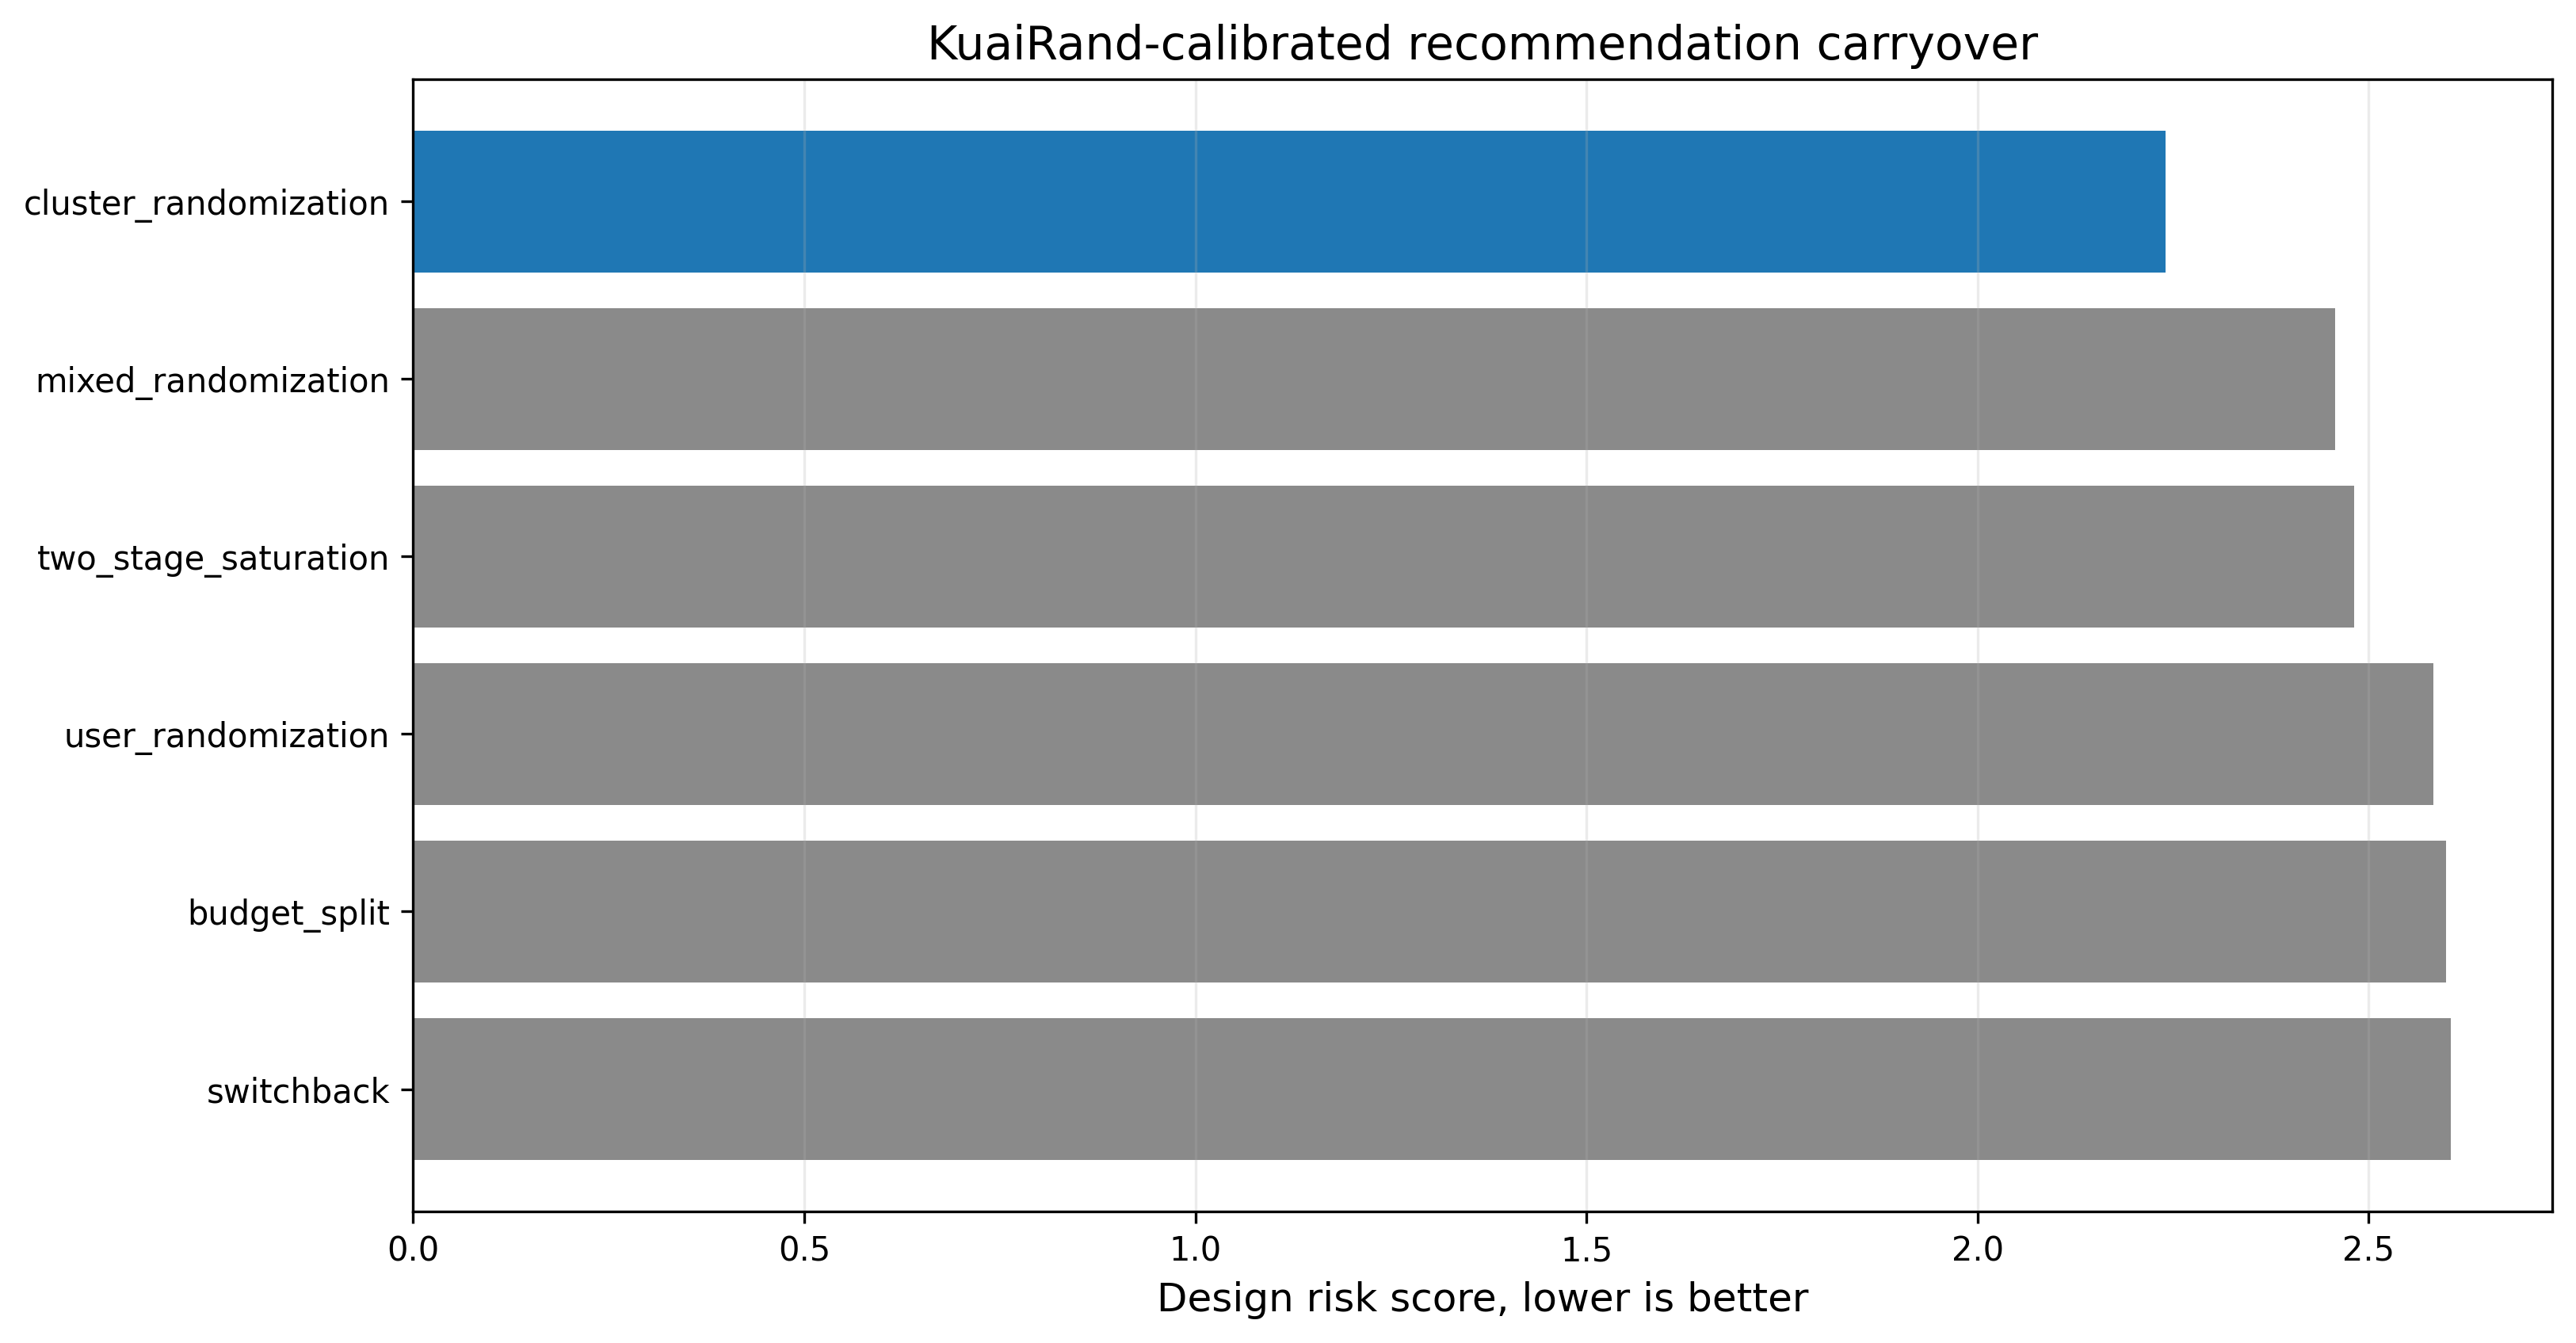

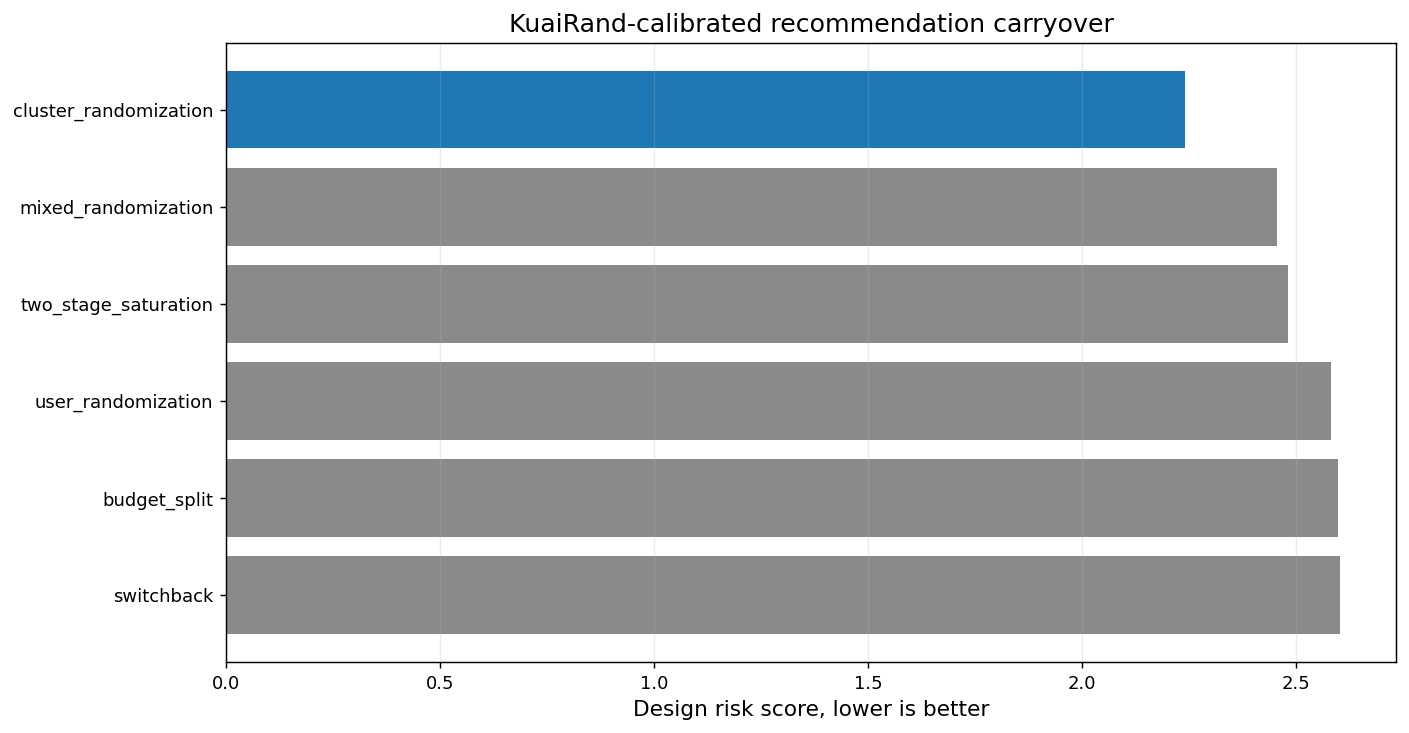

In [4]:
fig_path = paths.figure_dir / "04_kuairand_design_risk.png"
plot_design_risk(ranked, "KuaiRand-calibrated recommendation carryover", fig_path)
display(Image(filename=str(fig_path)))

[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/04_kuairand_bias_variance_frontier.png


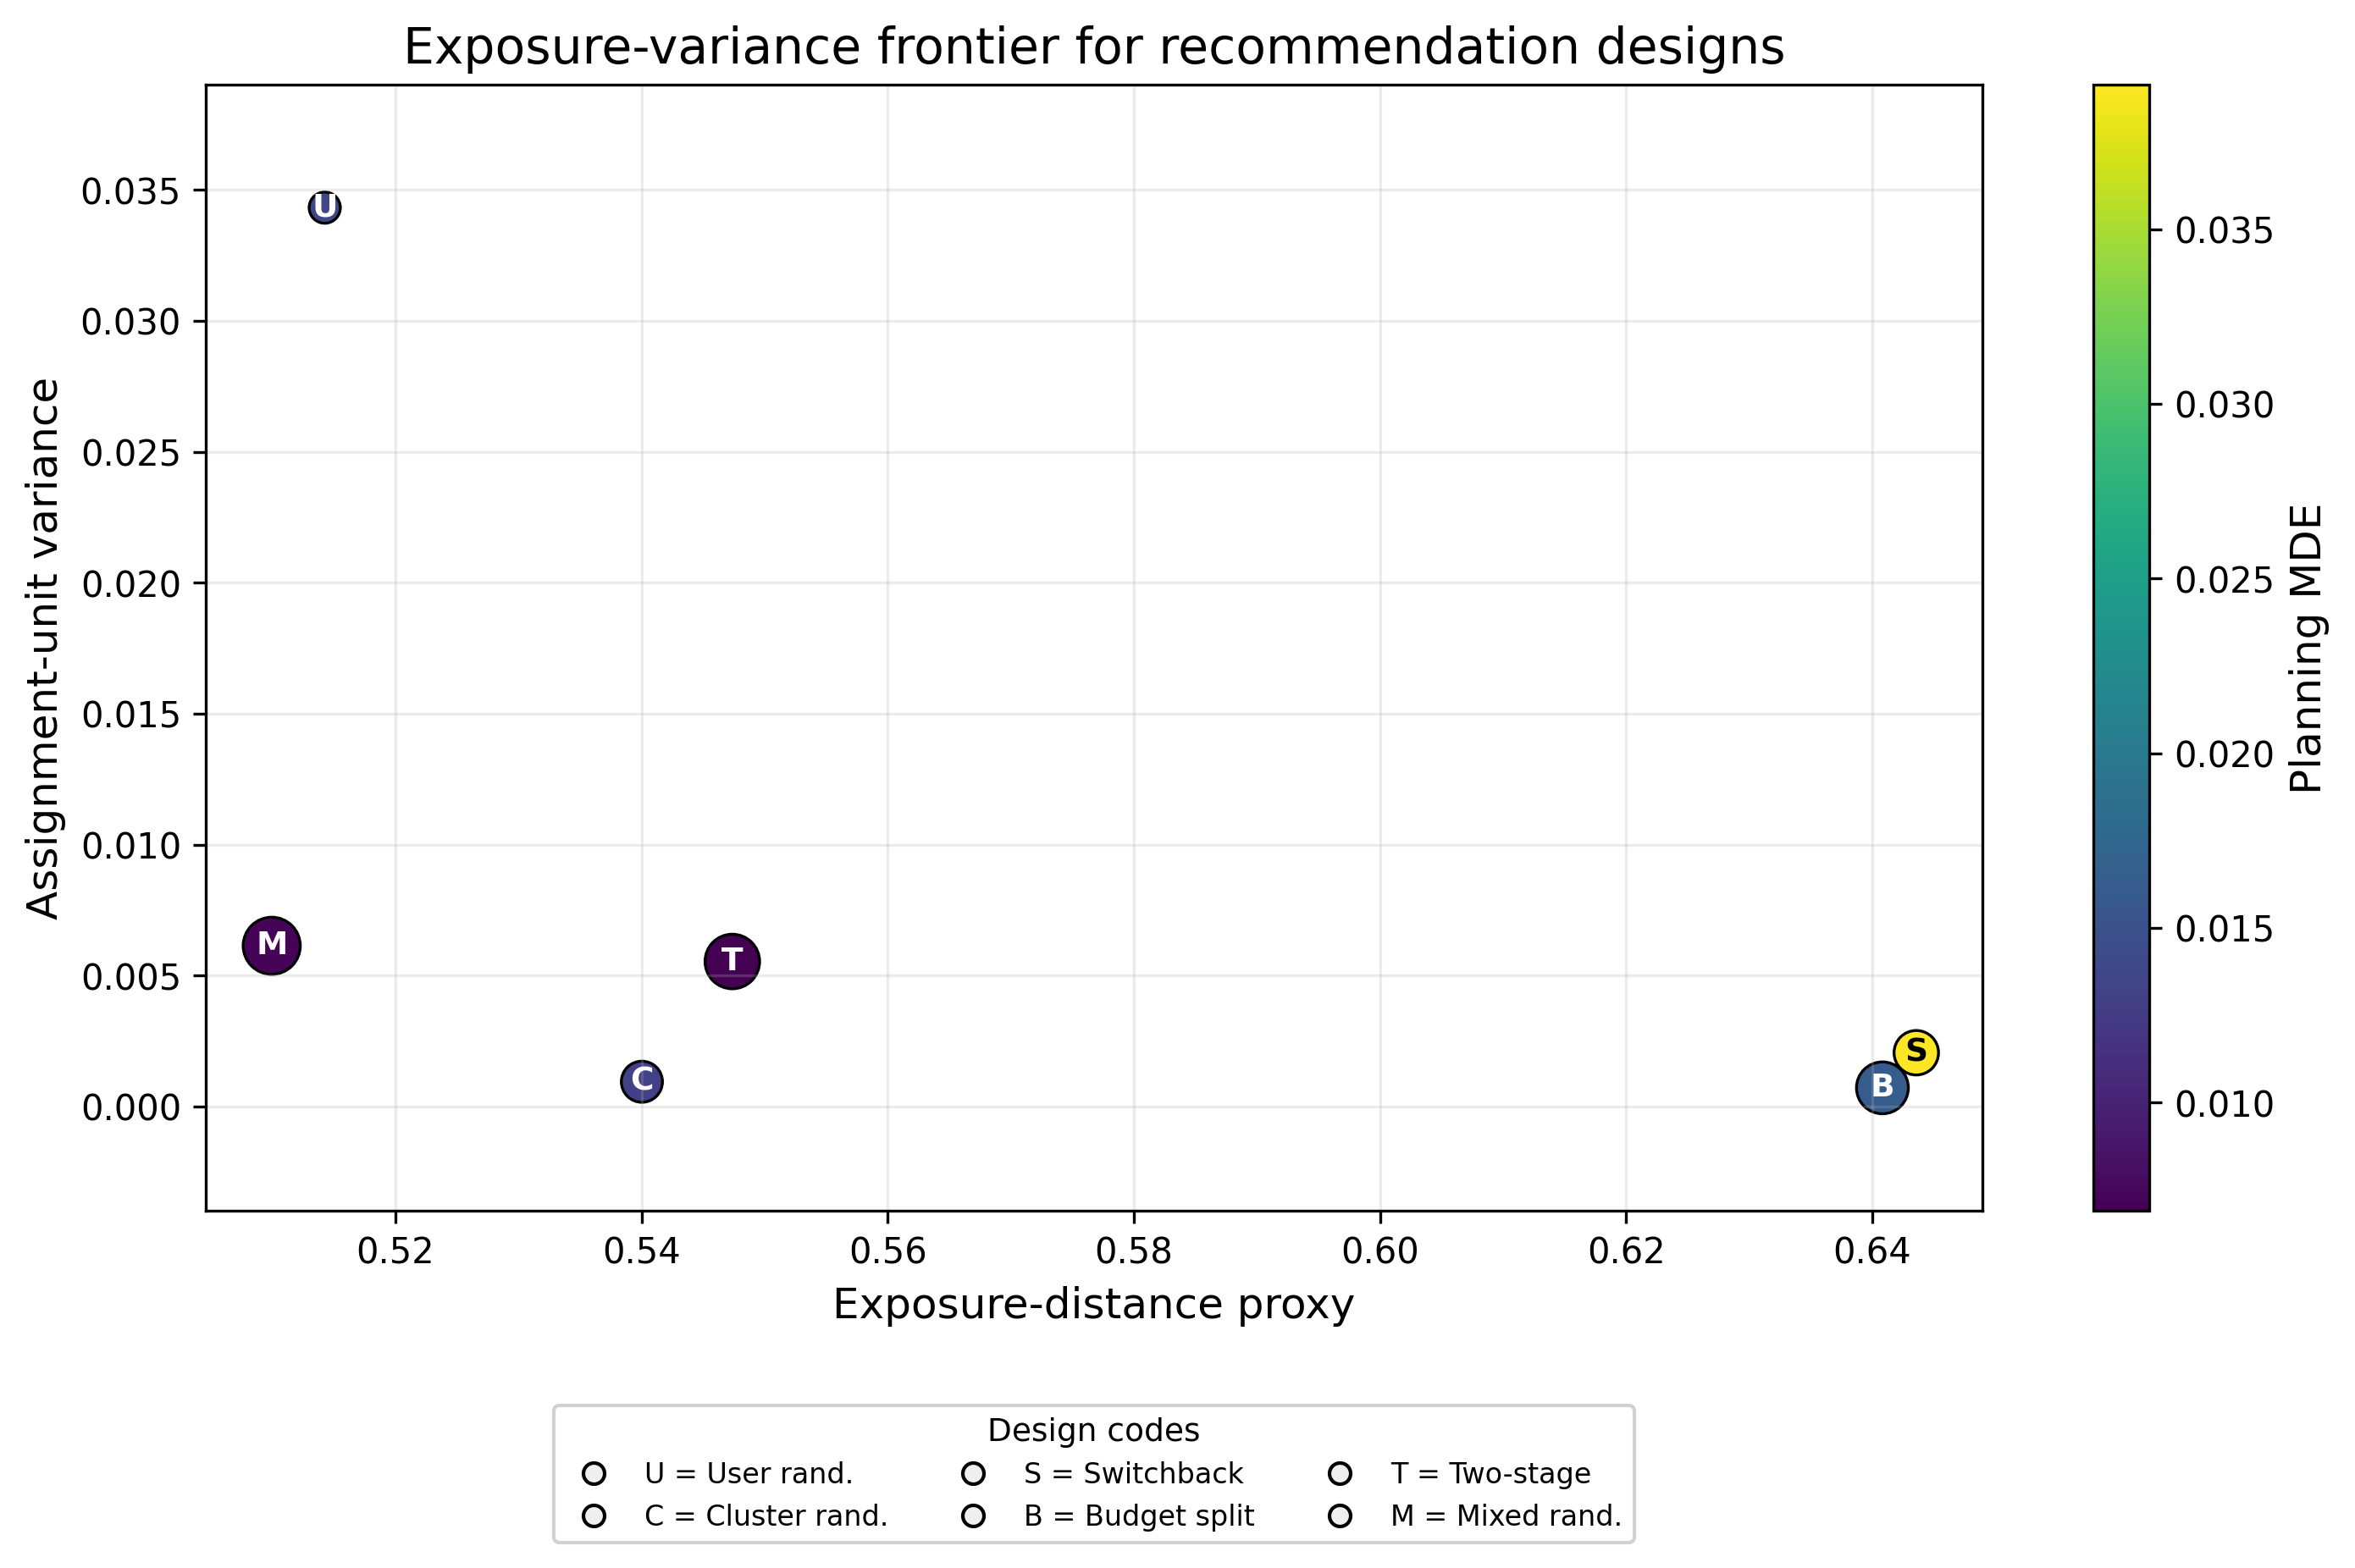

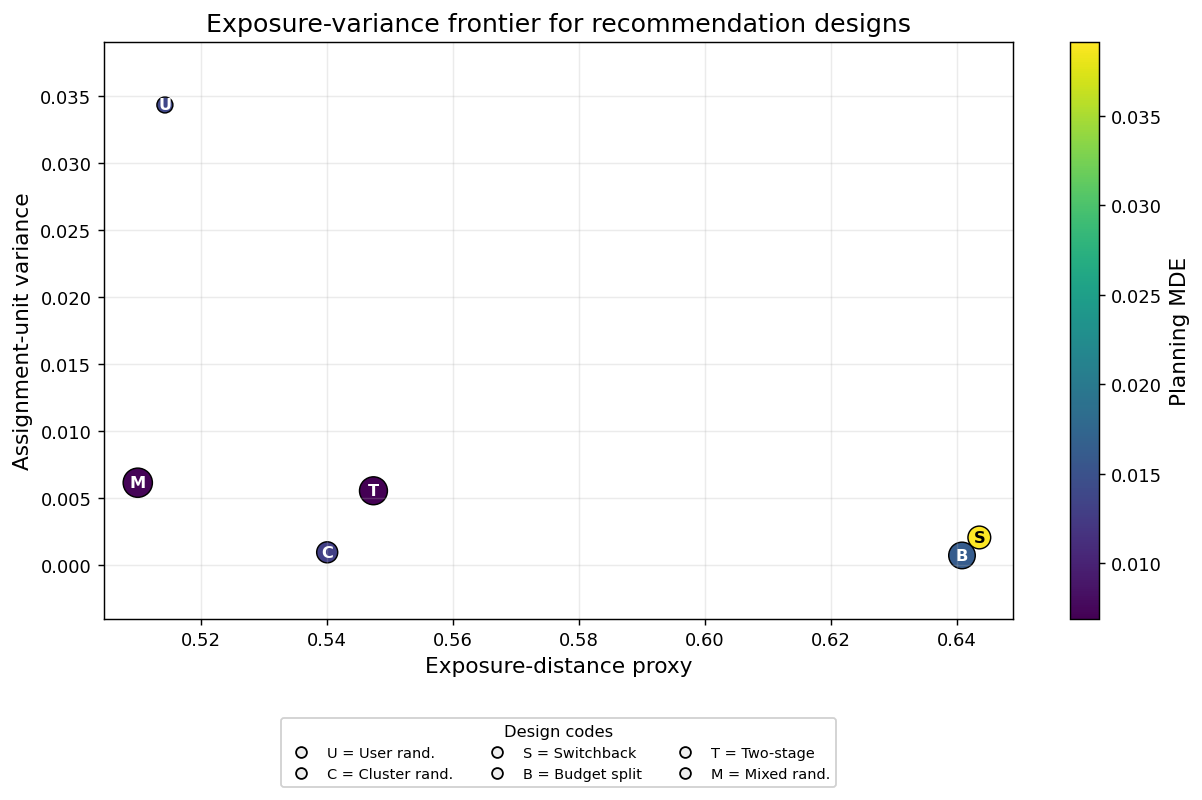

In [5]:
fig_path = paths.figure_dir / "04_kuairand_bias_variance_frontier.png"
plot_bias_variance_frontier(ranked, "Exposure-variance frontier for recommendation designs", fig_path)
display(Image(filename=str(fig_path)))